In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [23]:
problem_name = "convergence"
base_problem_name = "Portapilas-2x2-AA_0"
log_file = problem_name + "_log.csv"

data = pd.read_csv(log_file,sep=",")


#TODO: data has only problem_name starting with base_problem_name
data = data[data['problem_name'].str.startswith(base_problem_name)]

#strip whiet spaces from column names and all column values
data.columns = data.columns.str.strip()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].str.strip()

data['n_vertices'] = data['n_vertices'].astype(int)
data['num_non_zeros'] = data['num_non_zeros'].astype(int)
data['max_e_length'] = data['max_e_length'].astype(float)
data['l2_res_norm'] = data['l2_res_norm'].astype(float)
data['data_transfer_time_us'] = data['t_trans(us)'].astype(float)
data['solve_time_us'] = data['t_solve(us)'].astype(float)


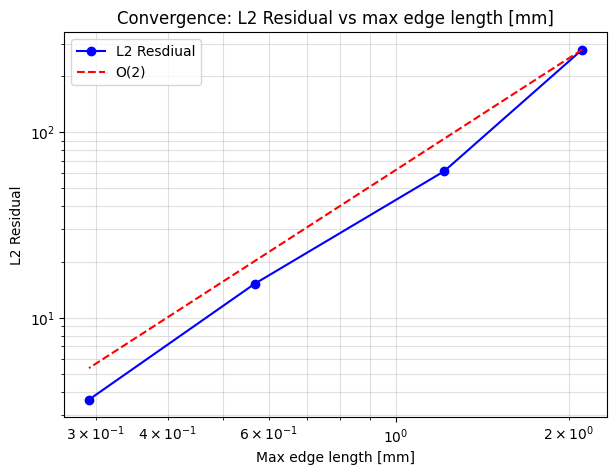

In [24]:
error_arr = data['l2_res_norm'].values
e_length_arr = data['max_e_length'].values

plt.figure(figsize=(7, 5))
plt.loglog(e_length_arr, error_arr, 'bo-', label='L2 Resdiual')

ref_line_max = [error_arr[0] * (v / e_length_arr[0])**(2) for v in e_length_arr]
plt.loglog(e_length_arr, ref_line_max, 'r--', label='O(2)')

plt.xlabel('Max edge length [mm]')
plt.ylabel('L2 Residual')
plt.title('Convergence: L2 Residual vs max edge length [mm]')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

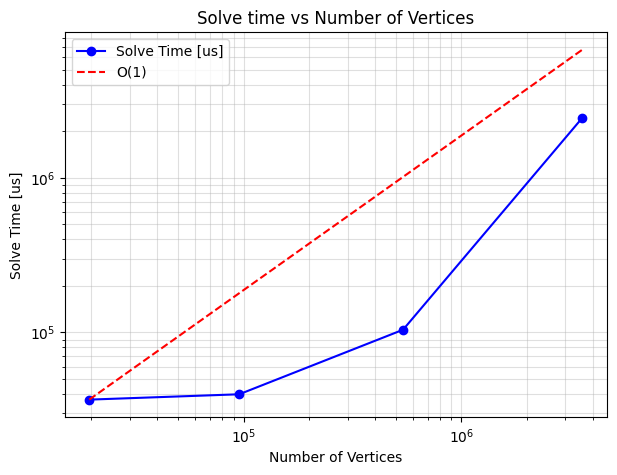

In [ ]:
runtime_arr = data['solve_time_us'].values
tran_time = data['data_transfer_time_us'].values
n_vertices_arr = data['n_vertices'].values

plt.figure(figsize=(7, 5))
plt.loglog(n_vertices_arr, runtime_arr, 'bo-', label='Solve Time [us]')
plt.loglog(n_vertices_arr, tran_time, 'go-', label='Data Transfer Time [us]')
ref_line_max = [runtime_arr[0] * (v / n_vertices_arr[0])**(1) for v in n_vertices_arr]
plt.loglog(n_vertices_arr, ref_line_max, 'r--', label='O(1)')

plt.xlabel('Number of Vertices')
plt.ylabel('Solve Time [us]')
plt.title('Solve time vs Number of Vertices')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

In [26]:
# Given from hlrs
"""
        Run the NeuroFEM simulation on SpiNNaker hardware and retrieve the solution.
        The sys_tick_in_s parameter should not be set too low, as then too many neuron spikes may be lost.

        :param timesteps: Number of simulation timesteps to run.
        :param sys_tick_in_s: System tick duration in seconds.
        :param mapping_only: If True, only perform the mapping without running.
        :return: The solution vector as a NumPy array.
        :rtype: np.ndarray

        from spinnaker2 import snn, hardware
        neuron_params = self._build_neuron_params()
        pop = snn.Population(size=self.nb_neurons, neuron_model="neurofem_2048", params=neuron_params, name=f"pop-neurofem-{id(self)}", record=["x_mean"])
        pop.set_max_atoms_per_core(self.neurons_per_core)

        conns = self._build_conns()
        proj = snn.Projection(pre=pop, post=pop, connections=conns, name=f"proj-neurofem-{id(self)}")

        net = snn.Network(f"net-neurofem-{id(self)}")
        net.add(pop, proj)

        # Run the network on SpiNNaker hardware
        hw = self.spinn_config.get_hardware()
        hw.run(net, timesteps, debug=False, sys_tick_in_s=sys_tick_in_s, mapping_only=mapping_only)

        x_mean = pop.get_x_mean()
        solution = self._get_solution(x_mean, timesteps)

        return solution

"""

'\n        Run the NeuroFEM simulation on SpiNNaker hardware and retrieve the solution.\n        The sys_tick_in_s parameter should not be set too low, as then too many neuron spikes may be lost.\n\n        :param timesteps: Number of simulation timesteps to run.\n        :param sys_tick_in_s: System tick duration in seconds.\n        :param mapping_only: If True, only perform the mapping without running.\n        :return: The solution vector as a NumPy array.\n        :rtype: np.ndarray\n\n        from spinnaker2 import snn, hardware\n        neuron_params = self._build_neuron_params()\n        pop = snn.Population(size=self.nb_neurons, neuron_model="neurofem_2048", params=neuron_params, name=f"pop-neurofem-{id(self)}", record=["x_mean"])\n        pop.set_max_atoms_per_core(self.neurons_per_core)\n\n        conns = self._build_conns()\n        proj = snn.Projection(pre=pop, post=pop, connections=conns, name=f"proj-neurofem-{id(self)}")\n\n        net = snn.Network(f"net-neurofem-{id(s